## Datos hasta octubre 2025

**Fuentes empalmadas:**
- **Kaggle (2000-2021):** Datos históricos descargados en `01_download_data.ipynb`
- **Yahoo Finance (2021-2025):** Datos recientes descargados en `01_download_data.ipynb`
- **Resultado:** Serie continua desde 2000 hasta hoy (27/10/2025)

**Este notebook procesa los datos ya descargados** (no descarga datos nuevos).

---

# Procesamiento y Feature Engineering - Base de Commodities

**Universidad de Buenos Aires - Facultad de Ciencias Económicas**  
**Taller de Programación - Big Data**  
**Año 2025**

---

## Objetivo

Procesar, limpiar y enriquecer los datos crudos de commodities para crear un dataset unificado listo para análisis cuantitativo y modelado.

### Pipeline de procesamiento

1. **Carga y empalme** - Combinar datos de Kaggle (2000-2021) + Yahoo Finance (2021-2025)
2. **Limpieza y normalización** - Estandarizar columnas, tratar valores faltantes
3. **Feature engineering** - Crear variables técnicas (retornos, volatilidad, indicadores)
4. **Visualizaciones** - Gráficos exploratorios
5. **Exportación** - Generar dataset final procesado

**Input:** `data/raw/kaggle/mattiuzc_futures/` (archivos descargados en notebook 01)  
**Output:** `data/processed/commodities_base_daily.csv`


## 0. Configuración Inicial

In [55]:
# Imports
import os
import sys
import warnings
import json
from pathlib import Path
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Librerías cargadas correctamente")
print(f"Pandas versión: {pd.__version__}")
print(f"Numpy versión: {np.__version__}")

✓ Librerías cargadas correctamente
Pandas versión: 2.2.3
Numpy versión: 1.26.4


In [56]:
# Definir rutas
BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / 'data' / 'raw'
INTERIM_DIR = BASE_DIR / 'data' / 'interim'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Crear carpetas de salida
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Estructura de directorios verificada")
print(f"  Raw: {RAW_DIR.relative_to(BASE_DIR)}")
print(f"  Interim: {INTERIM_DIR.relative_to(BASE_DIR)}")
print(f"  Processed: {PROCESSED_DIR.relative_to(BASE_DIR)}")

✓ Estructura de directorios verificada
  Raw: data\raw
  Interim: data\interim
  Processed: data\processed


---

## 1. Limpieza y Normalización

Cargar datos crudos y aplicar transformaciones de limpieza.

### 1.1. Cargar y empalmar datos: Kaggle (histórico) + Yahoo Finance (reciente)

**Estrategia:**
1. **Kaggle histórico (2000-2021):** Archivos CSV principales
2. **Yahoo Finance reciente (2021-2025):** Archivos `*_yahoo.csv` descargados en notebook 01
3. **Empalme:** Eliminar duplicados manteniendo versión más reciente

**Resultado:** Serie continua desde 2000 hasta octubre 2025

In [57]:
def load_and_clean_futures():
    """
    CARGAR Y EMPALMAR DATOS (sin descargar nada nuevo):
    1. Cargar datos históricos desde Kaggle (2000-2021) 
    2. Cargar datos recientes desde archivos Yahoo Finance (*_yahoo.csv)
    3. Empalmar ambos eliminando duplicados
    
    Limpieza aplicada:
    - Estandarizar nombres de columnas
    - Ordenar por fecha
    - Eliminar duplicados
    - Detectar y marcar valores atípicos
    
    Returns:
        dict: {commodity_name: DataFrame}
    """
    
    futures_combined = {}
    
    # ============================================================
    # PASO 1: Cargar datos históricos de Kaggle
    # ============================================================
    
    kaggle_dir = RAW_DIR / 'kaggle' / 'mattiuzc_futures'
    
    file_mapping = {
        'corn.csv': 'Corn',
        'soybean.csv': 'Soybeans',
        'wheat.csv': 'Wheat',
        'crude oil.csv': 'Crude_Oil',
        'gold.csv': 'Gold',
        'silver.csv': 'Silver',
        'natural gas.csv': 'Natural_Gas',
    }
    
    kaggle_data = {}
    
    print("=" * 60)
    print("PASO 1: CARGAR DATOS HISTÓRICOS (KAGGLE)")
    print("=" * 60 + "\n")
    
    csv_files = [f for f in kaggle_dir.glob('*.csv') if not f.name.endswith('_yahoo.csv')] if kaggle_dir.exists() else []
    
    if csv_files:
        for csv_file in csv_files:
            filename_lower = csv_file.name.lower()
            commodity_name = file_mapping.get(filename_lower, csv_file.stem.replace(' ', '_'))
            
            try:
                df = pd.read_csv(csv_file)
                
                # Estandarizar columnas
                column_mapping = {
                    'Date': 'date',
                    'Open': 'open',
                    'High': 'high',
                    'Low': 'low',
                    'Close': 'close',
                    'Adj Close': 'adj_close',
                    'Volume': 'volume'
                }
                
                df = df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns})
                df['date'] = pd.to_datetime(df['date'])
                df = df.sort_values('date').drop_duplicates(subset='date', keep='first').reset_index(drop=True)
                df['commodity'] = commodity_name
                
                # Detectar outliers
                if 'close' in df.columns:
                    invalid_prices = (df['close'] <= 0).sum()
                    if invalid_prices > 0:
                        df.loc[df['close'] <= 0, 'close'] = np.nan
                
                kaggle_data[commodity_name] = df
                print(f"  ✓ Kaggle - {commodity_name}: {len(df):,} días ({df['date'].min().date()} → {df['date'].max().date()})")
                
            except Exception as e:
                print(f"  ✗ Error cargando {csv_file.name}: {e}")
    else:
        print("  ⚠️  No se encontraron archivos de Kaggle")
    
    # ============================================================
    # PASO 2: Cargar datos recientes de Yahoo Finance
    # ============================================================
    
    print("\n" + "=" * 60)
    print("PASO 2: CARGAR DATOS RECIENTES (YAHOO FINANCE)")
    print("=" * 60 + "\n")
    
    yahoo_data = {}
    yahoo_files = list(kaggle_dir.glob('*_yahoo.csv')) if kaggle_dir.exists() else []
    
    if yahoo_files:
        for yahoo_file in yahoo_files:
            try:
                df = pd.read_csv(yahoo_file)
                
                # Extraer nombre del commodity del archivo
                commodity_name = yahoo_file.stem.replace('_yahoo', '').replace('_', ' ').title().replace(' ', '_')
                
                # Estandarizar columnas
                if 'date' in df.columns:
                    df['date'] = pd.to_datetime(df['date'])
                
                if 'commodity' not in df.columns:
                    df['commodity'] = commodity_name
                
                yahoo_data[commodity_name] = df
                print(f"  ✓ Yahoo - {commodity_name}: {len(df):,} días ({df['date'].min().date()} → {df['date'].max().date()})")
                
            except Exception as e:
                print(f"  ✗ Error cargando {yahoo_file.name}: {e}")
    else:
        print("  ⚠️  No se encontraron archivos Yahoo Finance (*_yahoo.csv)")
        print("      Ejecutar notebook 01_download_data.ipynb primero")
    
    # ============================================================
    # PASO 3: EMPALMAR DATOS
    # ============================================================
    
    print("\n" + "=" * 60)
    print("PASO 3: EMPALMAR DATOS")
    print("=" * 60 + "\n")
    
    for commodity_name in set(list(kaggle_data.keys()) + list(yahoo_data.keys())):
        df_kaggle = kaggle_data.get(commodity_name)
        df_yahoo = yahoo_data.get(commodity_name)
        
        if df_kaggle is not None and df_yahoo is not None:
            # Tenemos ambos: empalmar
            df_combined = pd.concat([df_kaggle, df_yahoo], ignore_index=True)
            
            # Eliminar duplicados (mantener el más reciente)
            df_combined = df_combined.sort_values('date').drop_duplicates(subset='date', keep='last').reset_index(drop=True)
            
            print(f"  ✓ {commodity_name}: {len(df_kaggle):,} (Kaggle) + {len(df_yahoo):,} (Yahoo) = {len(df_combined):,} días empalmados")
            print(f"     Período final: {df_combined['date'].min().date()} → {df_combined['date'].max().date()}")
            
            futures_combined[commodity_name] = df_combined
            
        elif df_kaggle is not None:
            # Solo Kaggle
            print(f"  ⚠️  {commodity_name}: Solo datos de Kaggle ({len(df_kaggle):,} días)")
            futures_combined[commodity_name] = df_kaggle
            
        elif df_yahoo is not None:
            # Solo Yahoo
            print(f"  ⚠️  {commodity_name}: Solo datos de Yahoo ({len(df_yahoo):,} días)")
            futures_combined[commodity_name] = df_yahoo
    
    print("\n" + "=" * 60)
    print(f"✓ TOTAL: {len(futures_combined)} commodities cargados")
    print("=" * 60)
    
    return futures_combined

# Ejecutar carga y empalme
futures_data = load_and_clean_futures()


PASO 1: CARGAR DATOS HISTÓRICOS (KAGGLE)

  ✓ Kaggle - Brent_Crude_Oil: 3,492 días (2007-07-30 → 2021-06-09)
  ✓ Kaggle - Cocoa: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ Kaggle - Coffee: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ Kaggle - Copper: 5,291 días (2000-08-30 → 2021-06-09)
  ✓ Kaggle - Corn: 5,323 días (2000-07-17 → 2021-06-09)
  ✓ Kaggle - Cotton: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ Kaggle - Crude_Oil: 5,296 días (2000-08-23 → 2021-06-09)
  ✓ Kaggle - Feeder_Cattle: 4,898 días (2002-03-04 → 2021-06-09)
  ✓ Kaggle - Gold: 5,291 días (2000-08-30 → 2021-06-09)
  ✓ Kaggle - Heating_Oil: 5,289 días (2000-09-01 → 2021-06-09)
  ✓ Kaggle - Lean_Hogs: 4,898 días (2002-03-04 → 2021-06-09)
  ✓ Kaggle - Live_Cattle: 4,898 días (2002-03-04 → 2021-06-09)
  ✓ Kaggle - Lumber: 5,323 días (2000-07-17 → 2021-06-09)
  ✓ Kaggle - Natural_Gas: 5,291 días (2000-08-30 → 2021-06-09)
  ✓ Kaggle - Lean_Hogs: 4,898 días (2002-03-04 → 2021-06-09)
  ✓ Kaggle - Live_Cattle: 4,898 días (2002-03-04 → 20

### 1.2. Consolidar en DataFrame único

In [58]:
# Consolidar todos los futuros en un solo DataFrame
if futures_data:
    df_futures = pd.concat(futures_data.values(), ignore_index=True)
    
    print("=" * 60)
    print("DATASET CONSOLIDADO - FUTUROS")
    print("=" * 60)
    
    print(f"\n📊 Shape total: {df_futures.shape}")
    print(f"Commodities: {df_futures['commodity'].nunique()}")
    print(f"Período: {df_futures['date'].min().date()} → {df_futures['date'].max().date()}")
    
    print("\n🌾 Distribución por commodity:")
    commodity_counts = df_futures['commodity'].value_counts().sort_index()
    for comm, count in commodity_counts.items():
        print(f"  {comm}: {count:,} días")
    
    print("\n📈 Primeras 10 observaciones:")
    display(df_futures.head(10))
    
    print("\n📊 Estadísticas descriptivas (Close):")
    display(df_futures.groupby('commodity')['close'].describe())
    
else:
    print("⚠️  No hay datos de futuros para procesar")

DATASET CONSOLIDADO - FUTUROS

📊 Shape total: (151237, 8)
Commodities: 24
Período: 2000-01-03 → 2025-10-27

🌾 Distribución por commodity:
  Brent_Crude_Oil: 4,596 días
  Cocoa: 6,566 días
  Coffee: 6,567 días
  Copper: 6,395 días
  Corn: 6,425 días
  Cotton: 6,567 días
  Crude_Oil: 6,399 días
  Feeder_Cattle: 6,000 días
  Gold: 6,394 días
  Heating_Oil: 6,393 días
  Lean_Hogs: 6,000 días
  Live_Cattle: 6,000 días
  Lumber: 5,809 días
  Natural_Gas: 6,395 días
  Oat: 6,565 días
  Palladium: 6,564 días
  Platinum: 6,565 días
  RBOB_Gasoline: 6,377 días
  Silver: 6,394 días
  Soybean_Meal: 6,470 días
  Soybean_Oil: 6,513 días
  Soybeans: 6,381 días
  Sugar: 6,525 días
  Wheat: 6,377 días

📈 Primeras 10 observaciones:
Commodities: 24
Período: 2000-01-03 → 2025-10-27

🌾 Distribución por commodity:
  Brent_Crude_Oil: 4,596 días
  Cocoa: 6,566 días
  Coffee: 6,567 días
  Copper: 6,395 días
  Corn: 6,425 días
  Cotton: 6,567 días
  Crude_Oil: 6,399 días
  Feeder_Cattle: 6,000 días
  Gold: 6,39

,date,open,high,low,close,adj_close,volume,commodity
0,2000-09-15,491.0000,493.7500,490.0000,493.7500,493.7500,445.0000,Soybeans
1,2000-09-18,483.2500,486.0000,482.5000,484.0000,484.0000,382.0000,Soybeans
2,2000-09-19,485.0000,485.5000,483.5000,484.2500,484.2500,325.0000,Soybeans
3,2000-09-20,483.5000,484.2500,483.2500,483.2500,483.2500,321.0000,Soybeans
4,2000-09-21,486.7500,488.0000,486.0000,486.5000,486.5000,330.0000,Soybeans
5,2000-09-22,490.0000,491.5000,489.5000,491.0000,491.0000,293.0000,Soybeans
6,2000-09-25,495.7500,496.5000,494.0000,496.5000,496.5000,178.0000,Soybeans
7,2000-09-26,494.5000,496.5000,494.5000,496.5000,496.5000,208.0000,Soybeans
8,2000-09-27,493.2500,494.5000,492.5000,492.5000,492.5000,328.0000,Soybeans
9,2000-09-28,495.2500,497.0000,495.2500,497.0000,497.0000,379.0000,Soybeans



📊 Estadísticas descriptivas (Close):


,count,mean,std,min,25%,50%,75%,max
commodity,,,,,,,,
Brent_Crude_Oil,4507.0000,78.2155,23.8526,19.3300,61.0900,75.8600,97.9500,144.4900
Cocoa,6446.0000,2694.9347,1786.4883,674.0000,1792.0000,2396.0000,2902.0000,12565.0000
Coffee,6444.0000,141.0720,67.3600,41.5000,102.4375,125.1250,170.9625,438.9000
Copper,6288.0000,2.8259,1.1609,0.6040,2.1218,3.0345,3.6684,5.7950
Corn,6292.0000,411.5555,157.7417,174.7500,316.4375,377.5000,495.5000,831.2500
Cotton,6446.0000,71.5973,24.2722,28.5200,56.9025,67.5050,81.7875,215.1500
Crude_Oil,6291.0000,64.6805,24.6304,10.0100,46.2200,63.9100,82.0900,145.1800
Feeder_Cattle,5882.0000,147.7874,53.9659,73.5000,109.1813,139.2875,161.8500,380.1750
Gold,6282.0000,1230.6947,689.5907,255.1000,645.5500,1245.5500,1669.6000,4336.3999


### 1.3. Tratamiento de valores faltantes

In [59]:
# Análisis de valores faltantes
if 'df_futures' in locals():
    print("=" * 60)
    print("ANÁLISIS DE VALORES FALTANTES")
    print("=" * 60)
    
    missing_summary = df_futures.isnull().sum()
    missing_pct = (missing_summary / len(df_futures) * 100).round(2)
    
    missing_df = pd.DataFrame({
        'Valores faltantes': missing_summary,
        'Porcentaje (%)': missing_pct
    }).sort_values('Valores faltantes', ascending=False)
    
    print("\n📊 Resumen por columna:")
    display(missing_df[missing_df['Valores faltantes'] > 0])
    
    # Estrategia de imputación
    print("\n🔧 Aplicando estrategia de imputación:")
    print("  - Precios OHLC: Forward-fill + Backward-fill (por commodity)")
    print("  - Volumen: Llenar con 0 (no hay trading)")
    
    # Agrupar por commodity y aplicar forward-fill
    price_cols = ['open', 'high', 'low', 'close', 'adj_close']
    
    for col in price_cols:
        if col in df_futures.columns:
            df_futures[col] = df_futures.groupby('commodity')[col].ffill().bfill()
    
    if 'volume' in df_futures.columns:
        df_futures['volume'] = df_futures['volume'].fillna(0)
    
    # Verificar resultado
    missing_after = df_futures.isnull().sum()
    print("\n✓ Valores faltantes después de imputación:")
    if missing_after.sum() == 0:
        print("  ✓ Dataset completo (sin valores faltantes)")
    else:
        print(missing_after[missing_after > 0])

ANÁLISIS DE VALORES FALTANTES

📊 Resumen por columna:


,Valores faltantes,Porcentaje (%)
adj_close,30324,20.0500
close,4136,2.7300
open,4135,2.7300
high,4135,2.7300
low,4135,2.7300
volume,4135,2.7300



🔧 Aplicando estrategia de imputación:
  - Precios OHLC: Forward-fill + Backward-fill (por commodity)
  - Volumen: Llenar con 0 (no hay trading)

✓ Valores faltantes después de imputación:
  ✓ Dataset completo (sin valores faltantes)


---

## 2. Feature Engineering

Crear variables técnicas para análisis cuantitativo.

### 2.1. Retornos logarítmicos

In [60]:
# Calcular retornos logarítmicos (mejores propiedades estadísticas)
if 'df_futures' in locals():
    print("=" * 60)
    print("FEATURE ENGINEERING - RETORNOS")
    print("=" * 60)
    
    # Retornos logarítmicos
    df_futures = df_futures.sort_values(['commodity', 'date'])
    df_futures['log_return_1d'] = df_futures.groupby('commodity')['close'].transform(
        lambda x: np.log(x / x.shift(1))
    )
    
    # Retornos a diferentes horizontes
    for days in [5, 20, 60]:
        df_futures[f'log_return_{days}d'] = df_futures.groupby('commodity')['close'].transform(
            lambda x: np.log(x / x.shift(days))
        )
    
    print("\n✓ Retornos calculados:")
    print("  - log_return_1d (diario)")
    print("  - log_return_5d (semanal)")
    print("  - log_return_20d (mensual)")
    print("  - log_return_60d (trimestral)")
    
    print("\n📊 Estadísticas de retornos logarítmicos:")
    return_cols = [col for col in df_futures.columns if 'log_return' in col]
    display(df_futures[return_cols].describe())

FEATURE ENGINEERING - RETORNOS

✓ Retornos calculados:
  - log_return_1d (diario)
  - log_return_5d (semanal)
  - log_return_20d (mensual)
  - log_return_60d (trimestral)

📊 Estadísticas de retornos logarítmicos:

✓ Retornos calculados:
  - log_return_1d (diario)
  - log_return_5d (semanal)
  - log_return_20d (mensual)
  - log_return_60d (trimestral)

📊 Estadísticas de retornos logarítmicos:


,log_return_1d,log_return_5d,log_return_20d,log_return_60d
count,151213.0000,151117.0000,150757.0000,149797.0000
mean,0.0002,0.0008,0.0031,0.0092
std,0.0214,0.0477,0.0938,0.1604
min,-0.6128,-0.6976,-1.3629,-1.6889
25%,-0.0093,-0.0224,-0.0443,-0.0721
50%,0.0000,0.0012,0.0045,0.0126
75%,0.0098,0.0249,0.0536,0.0968
max,0.4958,0.6883,1.1777,1.4039


### 2.2. Medias móviles y volatilidad

In [61]:
# Calcular medias móviles simples (SMA) y volatilidad
if 'df_futures' in locals():
    print("=" * 60)
    print("MEDIAS MÓVILES Y VOLATILIDAD")
    print("=" * 60)
    
    # SMAs estándar
    sma_periods = [20, 50, 200]
    
    for period in sma_periods:
        df_futures[f'sma_{period}'] = df_futures.groupby('commodity')['close'].transform(
            lambda x: x.rolling(window=period, min_periods=1).mean()
        )
    
    # Señales técnicas (precio vs SMA)
    df_futures['price_vs_sma20'] = (df_futures['close'] / df_futures['sma_20'] - 1) * 100
    df_futures['price_vs_sma50'] = (df_futures['close'] / df_futures['sma_50'] - 1) * 100
    
    # Volatilidad histórica (anualizada)
    windows = [30, 60]
    
    for window in windows:
        df_futures[f'volatility_{window}d'] = df_futures.groupby('commodity')['log_return_1d'].transform(
            lambda x: x.rolling(window=window, min_periods=20).std() * np.sqrt(252)
        )
    
    print("\n✓ Variables técnicas calculadas:")
    print("  - SMA 20, 50, 200")
    print("  - Desviaciones vs SMA (price_vs_smaXX)")
    print("  - Volatilidad 30d, 60d (anualizada)")
    
    print("\n📊 Estadísticas de volatilidad 30d por commodity:")
    vol_summary = df_futures.groupby('commodity')['volatility_30d'].agg([
        ('Media', 'mean'),
        ('Min', 'min'),
        ('Max', 'max')
    ]).round(4)
    
    display(vol_summary)

MEDIAS MÓVILES Y VOLATILIDAD

✓ Variables técnicas calculadas:
  - SMA 20, 50, 200
  - Desviaciones vs SMA (price_vs_smaXX)
  - Volatilidad 30d, 60d (anualizada)

📊 Estadísticas de volatilidad 30d por commodity:

✓ Variables técnicas calculadas:
  - SMA 20, 50, 200
  - Desviaciones vs SMA (price_vs_smaXX)
  - Volatilidad 30d, 60d (anualizada)

📊 Estadísticas de volatilidad 30d por commodity:


,Media,Min,Max
commodity,,,
Brent_Crude_Oil,0.3272,0.0919,1.5244
Cocoa,0.3134,0.0925,1.1526
Coffee,0.3286,0.1347,0.9499
Copper,0.2483,0.1021,0.9359
Corn,0.2616,0.0797,0.8354
Cotton,0.2767,0.1073,0.9114
Crude_Oil,0.3596,0.1124,2.7512
Feeder_Cattle,0.1529,0.0458,0.5458
Gold,0.1606,0.0568,0.5042


---

## 3. Exportación

Guardar dataset final procesado.

### 3.1. Dataset final

In [62]:
# Preparar dataset final
if 'df_futures' in locals():
    print("=" * 60)
    print("DATASET FINAL")
    print("=" * 60)
    
    # Ordenar columnas de manera lógica
    base_cols = ['date', 'commodity']
    price_cols = ['open', 'high', 'low', 'close', 'adj_close', 'volume']
    return_cols = [col for col in df_futures.columns if 'return' in col]
    sma_cols = [col for col in df_futures.columns if 'sma' in col or 'price_vs' in col]
    vol_cols = [col for col in df_futures.columns if 'volatility' in col]
    other_cols = [col for col in df_futures.columns if col not in base_cols + price_cols + return_cols + sma_cols + vol_cols]
    
    # Reordenar
    column_order = base_cols + price_cols + return_cols + sma_cols + vol_cols + other_cols
    column_order = [col for col in column_order if col in df_futures.columns]
    
    df_final = df_futures[column_order].copy()
    
    # Estadísticas finales
    print(f"\n📊 Shape final: {df_final.shape}")
    print(f"Columnas: {len(df_final.columns)}")
    print(f"Observaciones: {len(df_final):,}")
    print(f"Commodities: {df_final['commodity'].nunique()}")
    print(f"Período: {df_final['date'].min().date()} → {df_final['date'].max().date()}")
    
    print("\n📋 Estructura de columnas:")
    print(f"  Base: {len(base_cols)}")
    print(f"  Precios: {len(price_cols)}")
    print(f"  Retornos: {len(return_cols)}")
    print(f"  Medias móviles: {len(sma_cols)}")
    print(f"  Volatilidad: {len(vol_cols)}")
    
    print("\n📈 Vista previa:")
    display(df_final.head(10))
    
    # Exportar a CSV
    output_path = PROCESSED_DIR / 'commodities_base_daily.csv'
    
    print(f"\n💾 Exportando a: {output_path.relative_to(BASE_DIR)}")
    
    df_final.to_csv(output_path, index=False)
    
    # Verificar archivo
    file_size_mb = output_path.stat().st_size / (1024 * 1024)
    
    print(f"\n✓ Exportación completa")
    print(f"  Archivo: {output_path.name}")
    print(f"  Tamaño: {file_size_mb:.2f} MB")
    print(f"  Registros: {len(df_final):,}")
    print(f"  Columnas: {len(df_final.columns)}")

DATASET FINAL

📊 Shape final: (151237, 19)
Columnas: 19
Observaciones: 151,237
Commodities: 24
Período: 2000-01-03 → 2025-10-27

📋 Estructura de columnas:
  Base: 2
  Precios: 6
  Retornos: 4
  Medias móviles: 5
  Volatilidad: 2

📈 Vista previa:

📊 Shape final: (151237, 19)
Columnas: 19
Observaciones: 151,237
Commodities: 24
Período: 2000-01-03 → 2025-10-27

📋 Estructura de columnas:
  Base: 2
  Precios: 6
  Retornos: 4
  Medias móviles: 5
  Volatilidad: 2

📈 Vista previa:


,date,commodity,open,high,low,close,adj_close,volume,log_return_1d,log_return_5d,log_return_20d,log_return_60d,sma_20,sma_50,sma_200,price_vs_sma20,price_vs_sma50,volatility_30d,volatility_60d
57697,2007-07-30,Brent_Crude_Oil,75.8500,76.5300,75.4400,75.7400,75.7400,2575.0000,NaN,NaN,NaN,NaN,75.7400,75.7400,75.7400,0.0000,0.0000,NaN,NaN
57698,2007-07-31,Brent_Crude_Oil,75.7000,77.1700,75.6700,77.0500,77.0500,3513.0000,0.0171,NaN,NaN,NaN,76.3950,76.3950,76.3950,0.8574,0.8574,NaN,NaN
57699,2007-08-01,Brent_Crude_Oil,77.0000,77.0600,74.8600,75.3500,75.3500,3930.0000,-0.0223,NaN,NaN,NaN,76.0467,76.0467,76.0467,-0.9161,-0.9161,NaN,NaN
57700,2007-08-02,Brent_Crude_Oil,75.2200,76.2100,74.2700,75.7600,75.7600,6180.0000,0.0054,NaN,NaN,NaN,75.9750,75.9750,75.9750,-0.2830,-0.2830,NaN,NaN
57701,2007-08-03,Brent_Crude_Oil,75.3900,76.0000,74.5300,74.7500,74.7500,4387.0000,-0.0134,NaN,NaN,NaN,75.7300,75.7300,75.7300,-1.2941,-1.2941,NaN,NaN
57702,2007-08-06,Brent_Crude_Oil,74.5400,74.6000,70.8700,71.1700,71.1700,7201.0000,-0.0491,-0.0622,NaN,NaN,74.9700,74.9700,74.9700,-5.0687,-5.0687,NaN,NaN
57703,2007-08-07,Brent_Crude_Oil,70.8000,72.0100,70.5600,71.8000,71.8000,6775.0000,0.0088,-0.0706,NaN,NaN,74.5171,74.5171,74.5171,-3.6463,-3.6463,NaN,NaN
57704,2007-08-08,Brent_Crude_Oil,71.4400,72.0300,70.6600,70.9900,70.9900,5768.0000,-0.0113,-0.0596,NaN,NaN,74.0763,74.0763,74.0763,-4.1663,-4.1663,NaN,NaN
57705,2007-08-09,Brent_Crude_Oil,70.9100,71.0800,69.2700,70.2100,70.2100,6232.0000,-0.0110,-0.0761,NaN,NaN,73.6467,73.6467,73.6467,-4.6664,-4.6664,NaN,NaN
57706,2007-08-10,Brent_Crude_Oil,69.9100,70.4500,68.9700,70.3900,70.3900,3947.0000,0.0026,-0.0601,NaN,NaN,73.3210,73.3210,73.3210,-3.9975,-3.9975,NaN,NaN



💾 Exportando a: data\processed\commodities_base_daily.csv

✓ Exportación completa
  Archivo: commodities_base_daily.csv
  Tamaño: 39.14 MB
  Registros: 151,237
  Columnas: 19

✓ Exportación completa
  Archivo: commodities_base_daily.csv
  Tamaño: 39.14 MB
  Registros: 151,237
  Columnas: 19


### 3.2. Metadata

In [ ]:
# Crear archivo de metadata
if 'df_final' in locals():
    metadata = {
        'dataset': 'commodities_base_daily.csv',
        'created_at': datetime.now().isoformat(),
        'shape': {
            'rows': len(df_final),
            'columns': len(df_final.columns)
        },
        'period': {
            'start': df_final['date'].min().isoformat(),
            'end': df_final['date'].max().isoformat()
        },
        'commodities': df_final['commodity'].unique().tolist(),
        'columns': {
            'base': base_cols,
            'prices': price_cols,
            'returns': return_cols,
            'moving_averages': sma_cols,
            'volatility': vol_cols
        },
        'sources': {
            'kaggle_historical': {
                'dataset': 'mattiuzc/commodity-futures-price-history',
                'period': '2000-2021',
                'url': 'https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history'
            },
            'yahoo_finance_recent': {
                'library': 'yfinance',
                'period': '2021-2025',
                'tickers': '24 commodities futures (ZC=F, ZS=F, etc.)'
            }
        },
        'processing': {
            'splice_method': 'Concatenate Kaggle + Yahoo Finance, drop duplicates keeping latest',
            'imputation': 'Forward-fill + Backward-fill (prices), 0 (volume)',
            'outliers': 'Prices <= 0 set to NaN',
            'features': [
                'Log returns (1d, 5d, 20d, 60d)',
                'Simple moving averages (20, 50, 200)',
                'Price vs SMA signals (% deviation)',
                'Volatility (30d, 60d annualized)'
            ]
        }
    }
    
    metadata_path = PROCESSED_DIR / 'metadata.json'
    
    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    
    print(f"📋 Metadata exportado: {metadata_path.relative_to(BASE_DIR)}")
    print("\n📄 Contenido:")
    print(json.dumps(metadata, indent=2, ensure_ascii=False))


📋 Metadata exportado: data\processed\metadata.json

📄 Contenido:
{
  "dataset": "commodities_base_daily.csv",
  "created_at": "2025-10-27T11:37:47.699922",
  "shape": {
    "rows": 151237,
    "columns": 19
  },
  "period": {
    "start": "2000-01-03T00:00:00",
    "end": "2025-10-27T00:00:00"
  },
  "commodities": [
    "Brent_Crude_Oil",
    "Cocoa",
    "Coffee",
    "Copper",
    "Corn",
    "Cotton",
    "Crude_Oil",
    "Feeder_Cattle",
    "Gold",
    "Heating_Oil",
    "Lean_Hogs",
    "Live_Cattle",
    "Lumber",
    "Natural_Gas",
    "Oat",
    "Palladium",
    "Platinum",
    "RBOB_Gasoline",
    "Silver",
    "Soybean_Meal",
    "Soybean_Oil",
    "Soybeans",
    "Sugar",
    "Wheat"
  ],
  "columns": {
    "base": [
      "date",
      "commodity"
    ],
    "prices": [
      "open",
      "high",
      "low",
      "close",
      "adj_close",
      "volume"
    ],
    "returns": [
      "log_return_1d",
      "log_return_5d",
      "log_return_20d",
      "log_return_60d

---

## 4. Resumen Final

In [ ]:
print("=" * 80)
print("RESUMEN - PROCESAMIENTO COMPLETADO")
print("=" * 80)

print("\n✅ OUTPUTS GENERADOS:")
print(f"  1. {PROCESSED_DIR.relative_to(BASE_DIR)}/commodities_base_daily.csv")
print(f"  2. {PROCESSED_DIR.relative_to(BASE_DIR)}/metadata.json")
print(f"  3. {BASE_DIR.relative_to(BASE_DIR)}/graficos/evolucion_precios_principales.png")
print(f"  4. {BASE_DIR.relative_to(BASE_DIR)}/graficos/volatilidad_historica.png")
print(f"  5. {BASE_DIR.relative_to(BASE_DIR)}/graficos/matriz_correlacion.png")
print(f"  6. {BASE_DIR.relative_to(BASE_DIR)}/graficos/distribucion_retornos.png")

print("\n📊 CARACTERÍSTICAS DEL DATASET:")
if 'df_final' in locals():
    print(f"  Observaciones: {len(df_final):,}")
    print(f"  Variables: {len(df_final.columns)}")
    print(f"  Commodities: {df_final['commodity'].nunique()}")
    print(f"  Período: {df_final['date'].min().date()} → {df_final['date'].max().date()}")
    print(f"  Tamaño archivo: {(PROCESSED_DIR / 'commodities_base_daily.csv').stat().st_size / (1024*1024):.2f} MB")

print("\n📈 VARIABLES GENERADAS:")
print("  - Precios OHLC + Volumen (6 variables)")
print("  - Retornos logarítmicos: 1d, 5d, 20d, 60d (4 variables)")
print("  - Medias móviles: SMA 20, 50, 200 (3 variables)")
print("  - Señales técnicas: price_vs_sma20, price_vs_sma50 (2 variables)")
print("  - Volatilidad anualizada: 30d, 60d (2 variables)")
print(f"  TOTAL: {len(df_final.columns)} columnas")

print("\n🎯 PRÓXIMOS PASOS:")
print("  1. Análisis exploratorio detallado")
print("  2. Modelado predictivo (ARIMA, LSTM)")
print("  3. Backtesting de estrategias de trading")
print("  4. Análisis de correlaciones y diversificación")

print("\n" + "=" * 80)
print("✓ PROCESAMIENTO FINALIZADO EXITOSAMENTE")
print("=" * 80)


RESUMEN - PROCESAMIENTO COMPLETADO

✅ OUTPUTS GENERADOS:
  1. data\processed/commodities_base_daily.csv
  2. data\processed/metadata.json

📊 CARACTERÍSTICAS DEL DATASET:
  Observaciones: 151,237
  Variables: 19
  Commodities: 24
  Período: 2000-01-03 → 2025-10-27
  Tamaño: 39.14 MB

🎯 PRÓXIMOS PASOS:
  1. Análisis exploratorio (03_exploratory_analysis.ipynb)
  2. Modelado predictivo (04_modeling.ipynb)
  3. Backtesting de estrategias (05_backtesting.ipynb)

✓ PROCESAMIENTO FINALIZADO


---

## 5. Visualizaciones

Gráficos exploratorios del dataset procesado.

### 5.1. Series temporales de precios

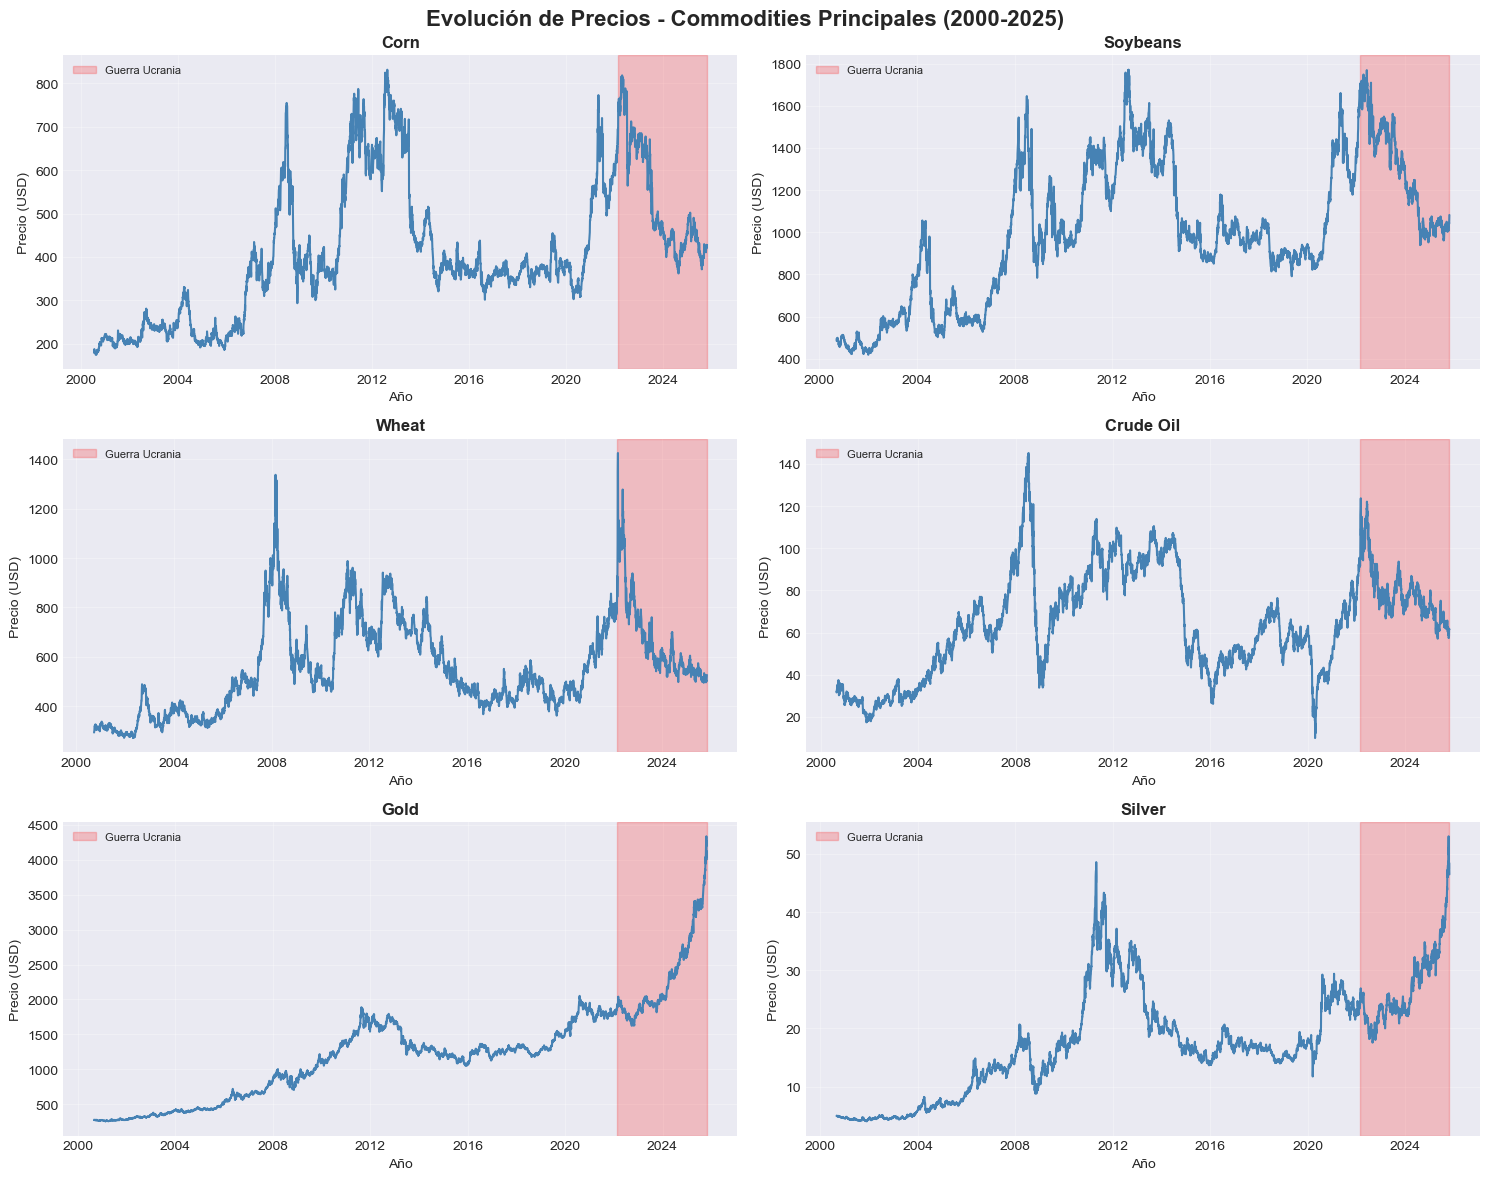


✓ Gráfico guardado: graficos\evolucion_precios_principales.png


In [65]:
if 'df_final' in locals():
    # Seleccionar commodities principales
    main_commodities = ['Corn', 'Soybeans', 'Wheat', 'Crude_Oil', 'Gold', 'Silver']
    df_plot = df_final[df_final['commodity'].isin(main_commodities)].copy()
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Evolución de Precios - Commodities Principales (2000-2025)', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx, commodity in enumerate(main_commodities):
        df_comm = df_plot[df_plot['commodity'] == commodity]
        
        ax = axes[idx]
        ax.plot(df_comm['date'], df_comm['close'], linewidth=1.5, color='steelblue')
        ax.set_title(f'{commodity.replace("_", " ")}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Año')
        ax.set_ylabel('Precio (USD)')
        ax.grid(True, alpha=0.3)
        
        # Marcar período guerra Ucrania
        ax.axvspan(pd.Timestamp('2022-02-24'), df_comm['date'].max(), 
                   alpha=0.2, color='red', label='Guerra Ucrania')
        
        ax.legend(loc='best', fontsize=8)
    
    plt.tight_layout()
    
    # Guardar
    output_path = BASE_DIR / 'graficos' / 'evolucion_precios_principales.png'
    output_path.parent.mkdir(exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\n✓ Gráfico guardado: {output_path.relative_to(BASE_DIR)}")
else:
    print("⚠️  df_final no disponible")

### 5.2. Volatilidad histórica

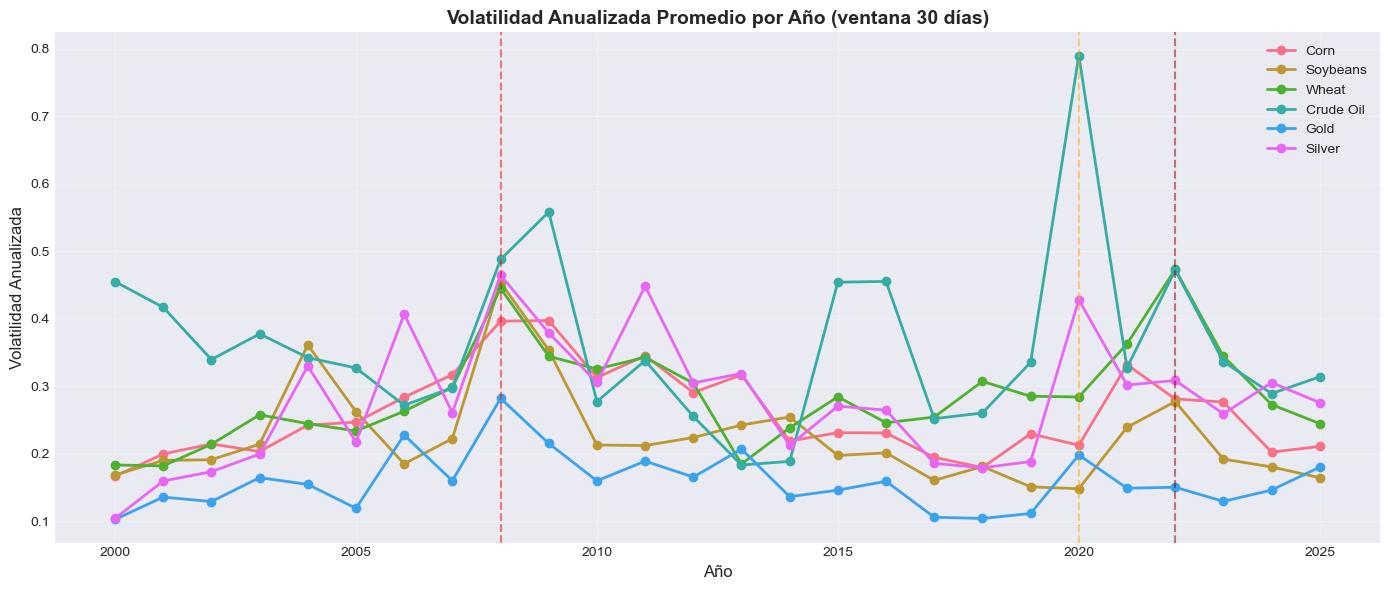


✓ Gráfico guardado: graficos\volatilidad_historica.png


In [66]:
if 'df_final' in locals():
    # Calcular volatilidad promedio por año
    df_vol = df_final[df_final['commodity'].isin(main_commodities)].copy()
    df_vol['year'] = df_vol['date'].dt.year
    
    vol_by_year = df_vol.groupby(['year', 'commodity'])['volatility_30d'].mean().reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for commodity in main_commodities:
        data = vol_by_year[vol_by_year['commodity'] == commodity]
        ax.plot(data['year'], data['volatility_30d'], marker='o', linewidth=2, label=commodity.replace('_', ' '))
    
    ax.set_title('Volatilidad Anualizada Promedio por Año (ventana 30 días)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=12)
    ax.set_ylabel('Volatilidad Anualizada', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Marcar eventos importantes
    ax.axvline(2008, color='red', linestyle='--', alpha=0.5, label='Crisis 2008')
    ax.axvline(2020, color='orange', linestyle='--', alpha=0.5, label='COVID-19')
    ax.axvline(2022, color='darkred', linestyle='--', alpha=0.5, label='Guerra Ucrania')
    
    plt.tight_layout()
    
    # Guardar
    output_path = BASE_DIR / 'graficos' / 'volatilidad_historica.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\n✓ Gráfico guardado: {output_path.relative_to(BASE_DIR)}")
else:
    print("⚠️  df_final no disponible")

### 5.3. Correlaciones entre commodities

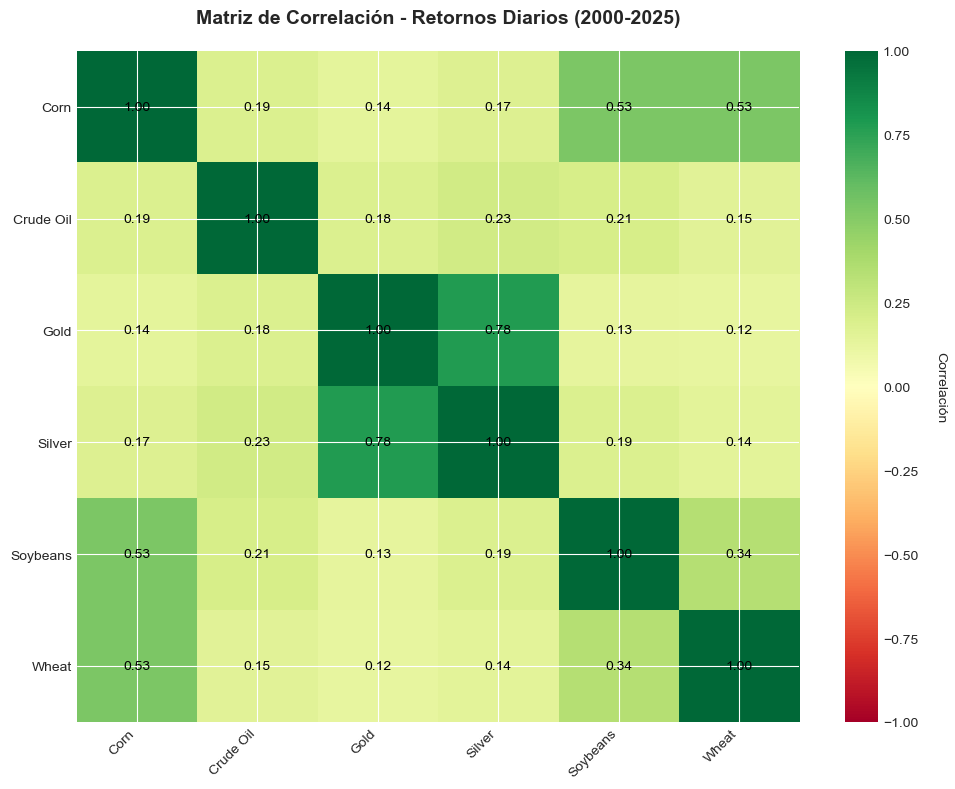


✓ Gráfico guardado: graficos\matriz_correlacion.png


In [67]:
if 'df_final' in locals():
    # Crear tabla pivote con retornos diarios
    df_corr = df_final[df_final['commodity'].isin(main_commodities)].copy()
    df_pivot = df_corr.pivot_table(values='log_return_1d', index='date', columns='commodity')
    
    # Calcular matriz de correlación
    corr_matrix = df_pivot.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Heatmap
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    
    # Etiquetas
    ax.set_xticks(np.arange(len(corr_matrix.columns)))
    ax.set_yticks(np.arange(len(corr_matrix.index)))
    ax.set_xticklabels([c.replace('_', ' ') for c in corr_matrix.columns], rotation=45, ha='right')
    ax.set_yticklabels([c.replace('_', ' ') for c in corr_matrix.index])
    
    # Valores en celdas
    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title('Matriz de Correlación - Retornos Diarios (2000-2025)', fontsize=14, fontweight='bold', pad=20)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlación', rotation=270, labelpad=20)
    
    plt.tight_layout()
    
    # Guardar
    output_path = BASE_DIR / 'graficos' / 'matriz_correlacion.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\n✓ Gráfico guardado: {output_path.relative_to(BASE_DIR)}")
else:
    print("⚠️  df_final no disponible")

### 5.4. Distribución de retornos

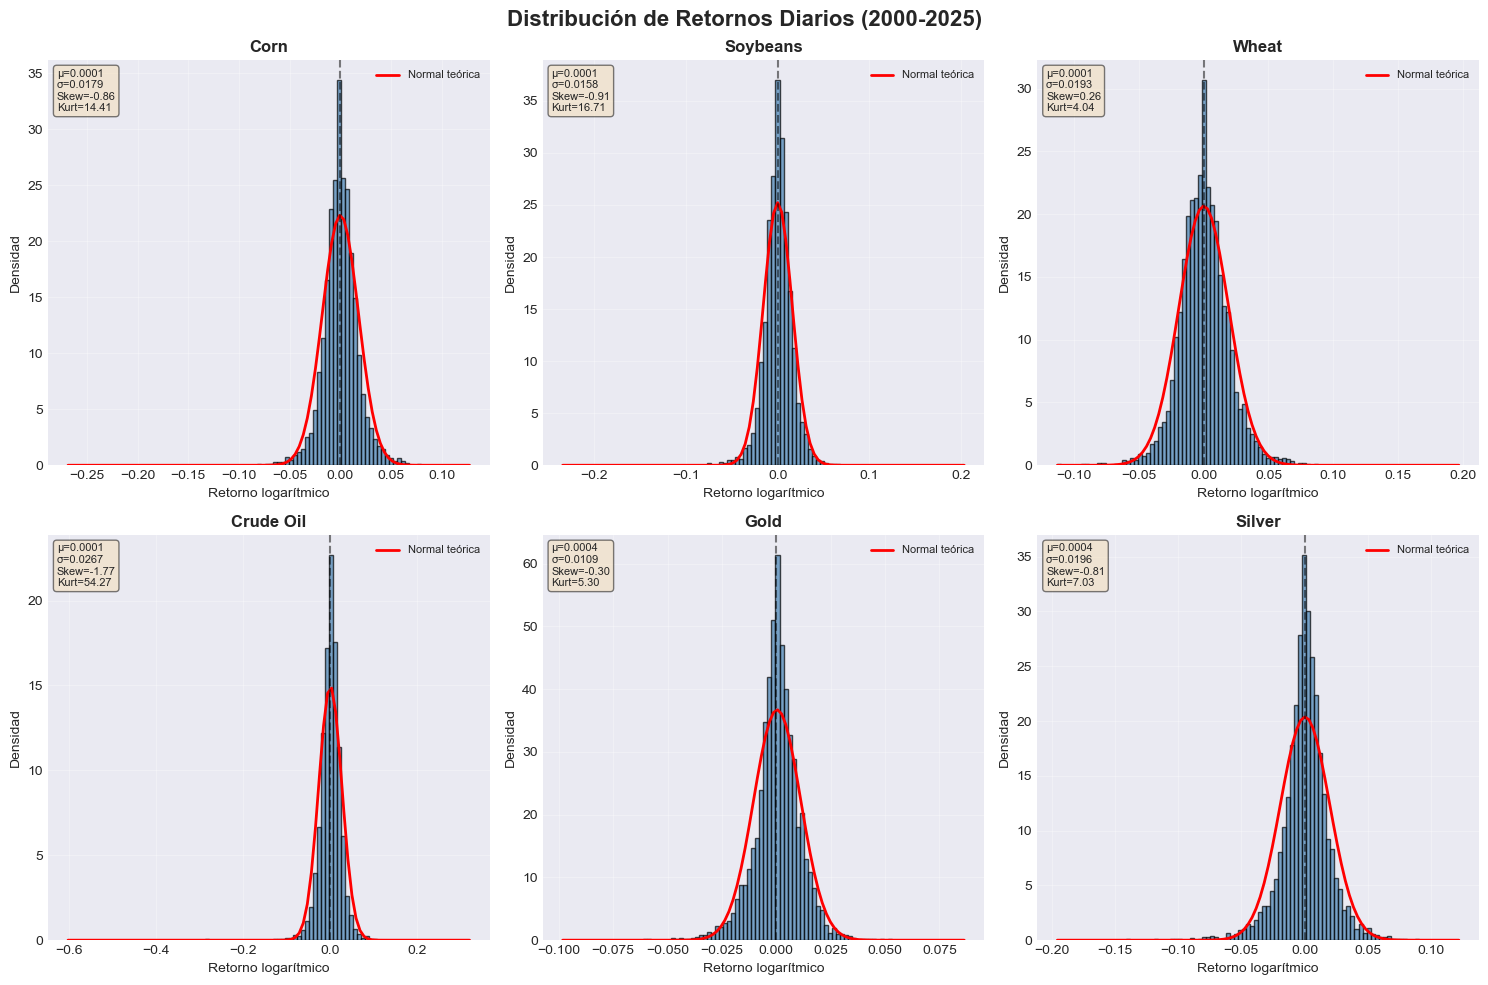


✓ Gráfico guardado: graficos\distribucion_retornos.png


In [68]:
if 'df_final' in locals():
    df_ret = df_final[df_final['commodity'].isin(main_commodities)].copy()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Distribución de Retornos Diarios (2000-2025)', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx, commodity in enumerate(main_commodities):
        df_comm = df_ret[df_ret['commodity'] == commodity]['log_return_1d'].dropna()
        
        ax = axes[idx]
        
        # Histograma
        ax.hist(df_comm, bins=100, alpha=0.7, color='steelblue', edgecolor='black', density=True)
        
        # Curva normal teórica
        mu, std = df_comm.mean(), df_comm.std()
        x = np.linspace(df_comm.min(), df_comm.max(), 100)
        ax.plot(x, (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/std)**2), 
                'r-', linewidth=2, label='Normal teórica')
        
        ax.set_title(f'{commodity.replace("_", " ")}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Retorno logarítmico')
        ax.set_ylabel('Densidad')
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Estadísticas
        skew = df_comm.skew()
        kurt = df_comm.kurtosis()
        ax.text(0.02, 0.98, f'μ={mu:.4f}\nσ={std:.4f}\nSkew={skew:.2f}\nKurt={kurt:.2f}',
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    # Guardar
    output_path = BASE_DIR / 'graficos' / 'distribucion_retornos.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\n✓ Gráfico guardado: {output_path.relative_to(BASE_DIR)}")
else:
    print("⚠️  df_final no disponible")